## Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns


## Loading and Inspecting the Dataset

In [3]:
df = pd.read_csv("/content/heart_disease_health_indicators.csv")
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (253661, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


## Checking for Missing Data

In [4]:
missing_data = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_data}")


Total Missing Values: 0


## Analyzing Class Distribution in Target Variable

In [5]:
print(df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100)


HeartDiseaseorAttack
0    90.582707
1     9.417293
Name: proportion, dtype: float64


# Splitting Features and Target

In [6]:
target = df['HeartDiseaseorAttack']
features = df.drop(columns=['HeartDiseaseorAttack'])


## Partitioning Data into Train, Validation, and Test Sets

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    features, target, test_size=0.2, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Training Set Size: {X_train.shape}")


Training Set Size: (202928, 21)


## Defining the Neural Network Architecture

In [8]:
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1408      
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

## Compiling the Model

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Training the Model

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=64,
    verbose=1
)


Epoch 1/50
3171/3171 [==============================] - 12s 3ms/step - loss: 0.2803 - accuracy: 0.8937 - val_loss: 0.2340 - val_accuracy: 0.9098
Epoch 2/50
3171/3171 [==============================] - 10s 3ms/step - loss: 0.2465 - accuracy: 0.9055 - val_loss: 0.2369 - val_accuracy: 0.9090
Epoch 3/50
3171/3171 [==============================] - 10s 3ms/step - loss: 0.2444 - accuracy: 0.9057 - val_loss: 0.2375 - val_accuracy: 0.9088
Epoch 4/50
3171/3171 [==============================] - 9s 3ms/step - loss: 0.2439 - accuracy: 0.9058 - val_loss: 0.2367 - val_accuracy: 0.9099
Epoch 5/50
3171/3171 [==============================] - 9s 3ms/step - loss: 0.2432 - accuracy: 0.9059 - val_loss: 0.2323 - val_accuracy: 0.9106
Epoch 6/50
3171/3171 [==============================] - 10s 3ms/step - loss: 0.2427 - accuracy: 0.9059 - val_loss: 0.2327 - val_accuracy: 0.9097
Epoch 7/50
3171/3171 [==============================] - 10s 3ms/step - loss: 0.2426 - accuracy: 0.9062 - val_loss: 0.2327 - val_accu

## Evaluating the Model on Test Data

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


793/793 [==============================] - 1s 1ms/step - loss: 0.2367 - accuracy: 0.9079
Test Accuracy: 0.9079


793/793 [==============================] - 1s 1ms/step


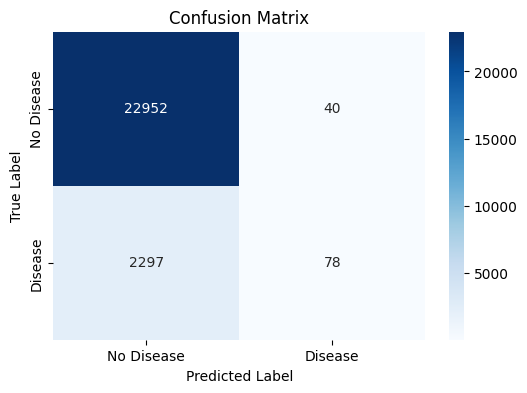

In [13]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Generating a Classification Report

In [14]:
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


              precision    recall  f1-score   support

  No Disease       0.91      1.00      0.95     22992
     Disease       0.66      0.03      0.06      2375

    accuracy                           0.91     25367
   macro avg       0.79      0.52      0.51     25367
weighted avg       0.89      0.91      0.87     25367



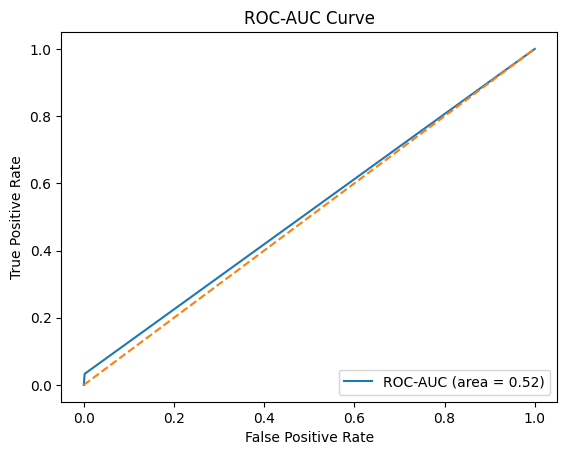

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC-AUC (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.show()


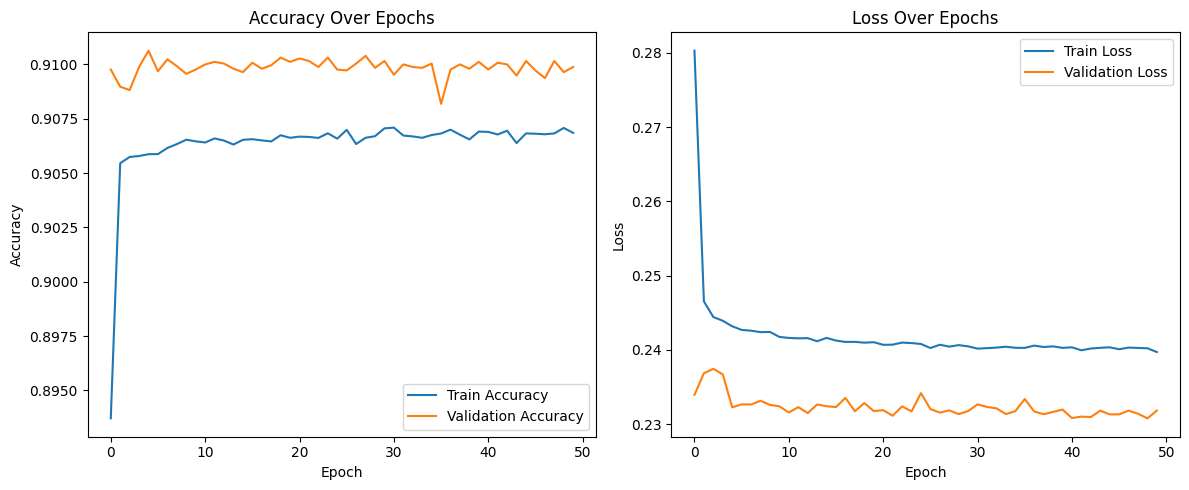

In [16]:
plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
